--- Dataset Shape ---
Rows: 2000, Columns: 17

--- Missing Values ---
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64 

--- Basic Stats ---


,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


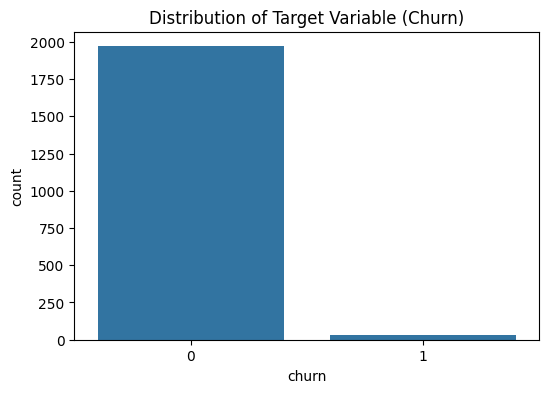

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Task 1: Dataset Understanding
df = pd.read_csv('customer_churn_nn.csv')

print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("--- Missing Values ---")
print(df.isnull().sum(), "\n")

print("--- Basic Stats ---")
display(df.describe())

# Target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='churn')
plt.title('Distribution of Target Variable (Churn)')
plt.show()

In [2]:
# Task 2: Data Preprocessing
# Dropping customer_id because it's just an identifier and won't help the model learn
df = df.drop('customer_id', axis=1)

# Separate features (X) and target (y)
X = df.drop('churn', axis=1)
y = df['churn']

# Identify categorical and numerical columns
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# One-hot encode categorical features (creates dummy variables)
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the numerical features so large numbers don't dominate the neural network
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (1600, 24)
Testing data shape: (400, 24)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting training...
Training complete!


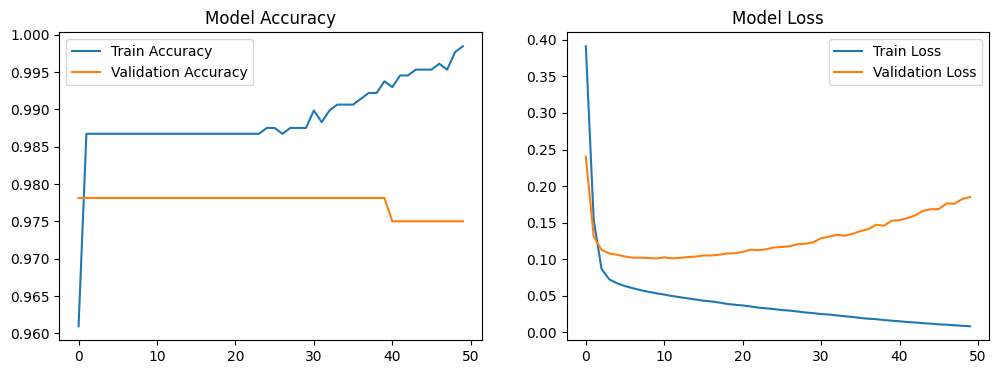


Test Accuracy: 0.9775
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


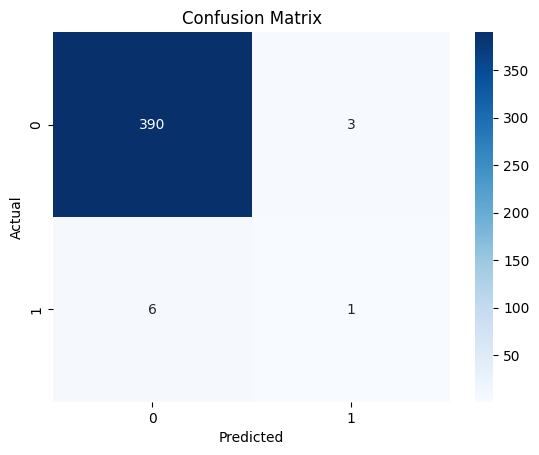


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       393
           1       0.25      0.14      0.18         7

    accuracy                           0.98       400
   macro avg       0.62      0.57      0.59       400
weighted avg       0.97      0.98      0.97       400



In [3]:
# Task 3: Neural Network Model Building
# Building a standard feed-forward neural network
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)), # Input + 1st Hidden layer
    Dense(16, activation='relu'),                                  # 2nd Hidden layer
    Dense(1, activation='sigmoid')                                 # Output layer (sigmoid for binary classification)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Task 4: Training the model
print("Starting training...")
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
print("Training complete!")

# Plotting the training progress
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

# Evaluation on Test Data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [4]:
# Task 5: Hyperparameter Experimentation
experiments = [
    {'name': 'Exp 1: Baseline', 'layers': [32, 16], 'lr': 0.001, 'batch': 32, 'epochs': 50},
    {'name': 'Exp 2: Wider Network', 'layers': [64, 32, 16], 'lr': 0.001, 'batch': 32, 'epochs': 50},
    {'name': 'Exp 3: High Learning Rate', 'layers': [32, 16], 'lr': 0.01, 'batch': 64, 'epochs': 30}
]

results = []

for exp in experiments:
    tf.keras.backend.clear_session()

    # Build model based on experiment configs
    exp_model = Sequential()
    exp_model.add(Dense(exp['layers'][0], activation='relu', input_shape=(X_train.shape[1],)))

    for neurons in exp['layers'][1:]:
        exp_model.add(Dense(neurons, activation='relu'))

    exp_model.add(Dense(1, activation='sigmoid'))

    optimizer = tf.keras.optimizers.Adam(learning_rate=exp['lr'])
    exp_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    exp_model.fit(X_train, y_train, epochs=exp['epochs'], batch_size=exp['batch'], verbose=0)

    _, test_acc = exp_model.evaluate(X_test, y_test, verbose=0)

    results.append({
        'Experiment': exp['name'],
        'Architecture': str(exp['layers']),
        'Learning Rate': exp['lr'],
        'Batch Size': exp['batch'],
        'Test Accuracy': round(test_acc, 4)
    })

# Display comparison table
results_df = pd.DataFrame(results)
display(results_df)
# You can save this to csv for your results folder:
# results_df.to_csv('results/model_comparison_table.csv', index=False)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Experiment,Architecture,Learning Rate,Batch Size,Test Accuracy
0,Exp 1: Baseline,"[32, 16]",0.001,32,0.9825
1,Exp 2: Wider Network,"[64, 32, 16]",0.001,32,0.9775
2,Exp 3: High Learning Rate,"[32, 16]",0.010,64,0.9700
